# Exploratory Data Analysis (EDA) Project

## Project Overview

This project focuses on performing Exploratory Data Analysis (EDA) on a transactional sales dataset as part of the Decodelabs Data Analytics Internship program.

The objective of the analysis is to understand customer purchasing behavior, identify trends and patterns within the dataset, detect outliers, and generate meaningful insights from the data.

The project includes:
- Data cleaning and preprocessing
- Descriptive statistical analysis
- Trend analysis
- Distribution analysis
- Outlier detection
- Visualization of key metrics
- Summary of analytical observations

Tools and Technologies Used:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

The insights generated from this analysis provide a better understanding of sales performance, product demand, customer purchasing patterns, and transaction behavior.

## Importing Required Libraries

In [ ]:
# import libraries for data analysis and visualiztions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

## Loading the Dataset

In [ ]:
# Load the Excel dataset into a pandas DataFrame
df = pd.read_excel('/content/Dataset for Data Analytics.xlsx')

## Previewing the Dataset

In [ ]:
# Display the first 5 rows of the dataset
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


# Data Cleaning and Preprocessing

In [ ]:
# Display dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [ ]:
df.shape

(1200, 14)

In [ ]:
# Check for missing values in each column
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


## Handling Missing Value in Couponcode Column

In [ ]:
# Replace missing CouponCode values with 'No Coupon'

df['CouponCode'] = df['CouponCode'].fillna('No Coupon')

In [ ]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [ ]:
## Checking for Duplicate
df.duplicated().sum()

np.int64(0)

In [ ]:
# Standardize text formatting in categorical columns

text_columns = ['Product', 'PaymentMethod', 'OrderStatus', 'ReferralSource']

for col in text_columns:
    df[col] = df[col].str.strip().str.title()

In [ ]:
## Changing the Date datatype
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
## Validating Total Price
df['CalculatedTotal'] = df['Quantity'] * df['UnitPrice']

df[['Quantity', 'UnitPrice', 'TotalPrice', 'CalculatedTotal']].head()

,Quantity,UnitPrice,TotalPrice,CalculatedTotal
0,5,570.62,2853.10,2853.10
1,2,151.35,302.70,302.70
2,5,550.68,2753.40,2753.40
3,1,273.19,273.19,273.19
4,4,626.01,2504.04,2504.04


In [ ]:
# Generate descriptive statistics for all numerical columns
# This shows:
# - count
# - mean
# - standard deviation
# - minimum value
# - quartiles
# - maximum value

df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice,CalculatedTotal
count,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558,819.856558


In [ ]:
# Calculate the median for all numerical columns
# Helps to understand the middle value of the dataset

df.median(numeric_only=True)

,0
Quantity,3.000
UnitPrice,364.210
ItemsInCart,5.000
TotalPrice,823.615
CalculatedTotal,823.615


In [ ]:
# Count the number of non-missing records in each column
# This helps confirm data completeness after cleaning

df.count()

,0
OrderID,1200
Date,1200
CustomerID,1200
Product,1200
Quantity,1200
UnitPrice,1200
ShippingAddress,1200
PaymentMethod,1200
OrderStatus,1200
TrackingNumber,1200


In [ ]:
# Count how many times each payment method was used
# Helps identify the most preferred payment option

df['PaymentMethod'].value_counts()

,count
PaymentMethod,
Online,258
Cash,246
Credit Card,234
Debit Card,232
Gift Card,230


In [ ]:
# Count the number of orders by status
# Helps evaluate delivery and cancellation patterns

df['OrderStatus'].value_counts()

,count
OrderStatus,
Cancelled,250
Returned,247
Pending,237
Shipped,235
Delivered,231


In [ ]:
# Count how many times each product appears
# Helps identify the most frequently purchased products

df['Product'].value_counts()

,count
Product,
Printer,181
Tablet,179
Chair,178
Laptop,173
Desk,170
Monitor,163
Phone,156


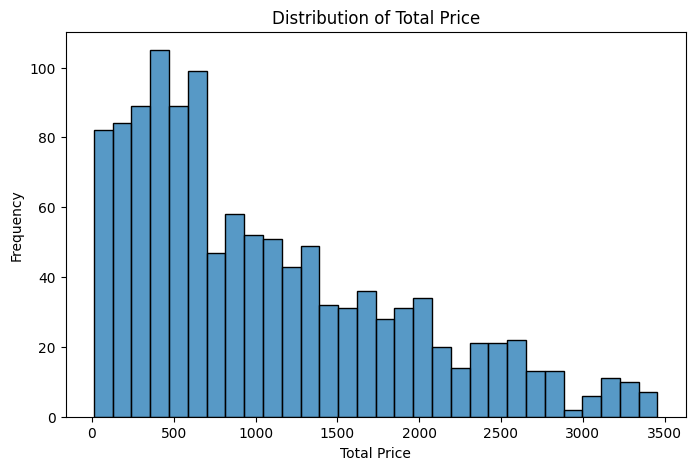

In [ ]:
# Plot the distribution of TotalPrice
# Helps us understand how order values are spread

plt.figure(figsize=(8,5))

sns.histplot(df['TotalPrice'], bins=30)

# Add chart title and labels
plt.title('Distribution of Total Price')
plt.xlabel('Total Price')
plt.ylabel('Frequency')

# Display the chart
plt.show()

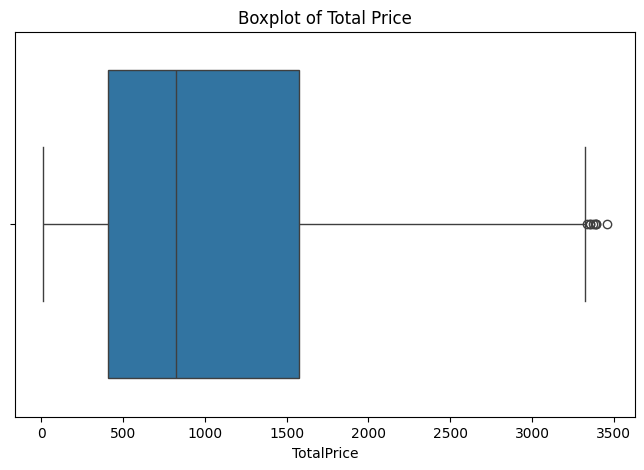

In [ ]:
# Create a boxplot to detect outliers in TotalPrice
# Outliers are unusually high or low values

plt.figure(figsize=(8,5))

sns.boxplot(x=df['TotalPrice'])

# Add chart title
plt.title('Boxplot of Total Price')

# Display chart
plt.show()

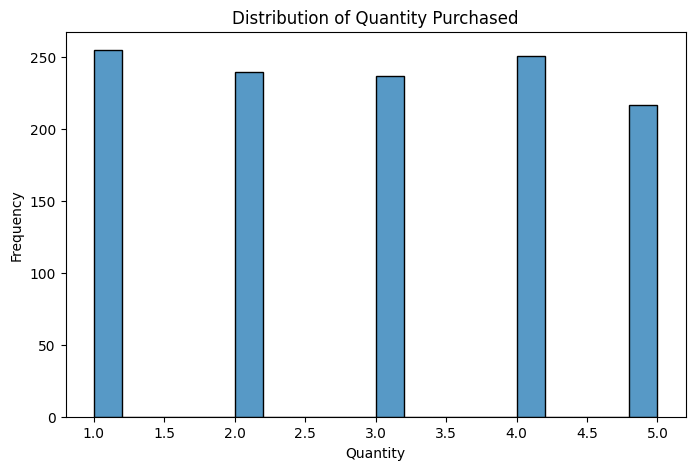

In [ ]:
# Visualize how product quantities are distributed
# Helps identify common purchase quantities

plt.figure(figsize=(8,5))

sns.histplot(df['Quantity'], bins=20)

# Add chart title and labels
plt.title('Distribution of Quantity Purchased')
plt.xlabel('Quantity')
plt.ylabel('Frequency')

# Display chart
plt.show()

In [ ]:
# Extract the month from the Date column
# This will help us analyze monthly trends

df['Month'] = df['Date'].dt.month

In [ ]:
# Group data by month and calculate total revenue
# Helps identify revenue trends over time

monthly_sales = df.groupby('Month')['TotalPrice'].sum()

# Display monthly revenue
monthly_sales

,TotalPrice
Month,
1,124313.23
2,112344.78
3,123840.93
4,109186.05
5,135142.59
6,170616.13
7,85784.64
8,86343.21
9,69321.65


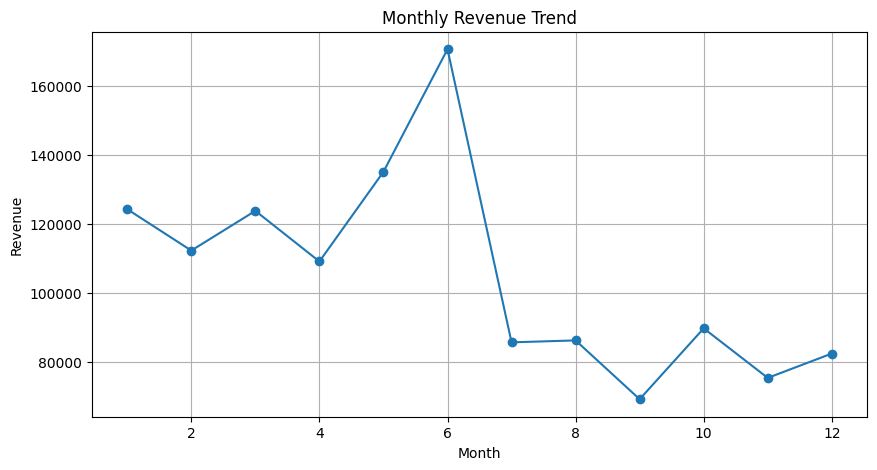

In [ ]:
# Plot monthly revenue trend
# Helps identify peak and low sales periods

plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

# Add chart title and labels
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

# Add grid for better readability
plt.grid(True)

# Display chart
plt.show()

In [ ]:
# Calculate total revenue generated by each product
# Helps identify top-performing products

product_sales = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

# Display product revenue
product_sales

,TotalPrice
Product,
Chair,195620.11
Printer,195612.61
Laptop,192126.56
Tablet,186568.95
Monitor,175651.41
Desk,167459.93
Phone,151722.39


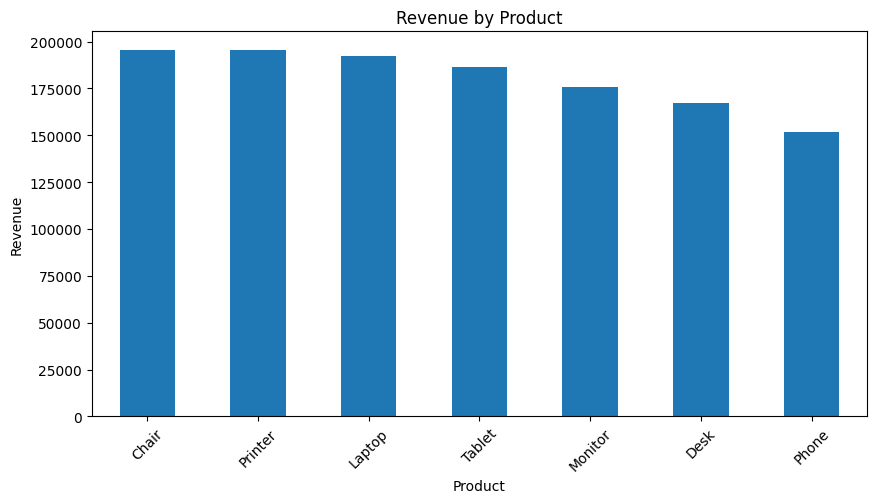

In [ ]:
# Create a bar chart showing revenue by product
# Helps compare product performance visually

plt.figure(figsize=(10,5))

product_sales.plot(kind='bar')

# Add chart title and labels
plt.title('Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Revenue')

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Display chart
plt.show()

## Key Observations

1. The dataset contains 1,200 transaction records with no major missing values after data cleaning, making it suitable for analysis.

2. The average quantity purchased per transaction was approximately 3 items, while the average total transaction value was about 1,054, indicating moderate customer spending behavior.

3. The distribution of TotalPrice was positively skewed, showing that most transactions were concentrated around lower and mid-range values, with fewer high-value purchases.

4. The boxplot analysis identified a few high-value outliers in TotalPrice, suggesting the presence of unusually large transactions or bulk purchases.

5. Monthly revenue fluctuated throughout the year, with a noticeable revenue peak around Month 6 before declining in subsequent months.

6. Product performance analysis showed that Chair, Monitor, and Laptop generated the highest revenue among all products, indicating stronger customer demand for these items.

7. Online payment was the most frequently used payment method, showing a higher customer preference for digital transactions.

8. Order status distribution was relatively balanced across categories such as Cancelled, Returned, Pending, Shipped, and Delivered, indicating varied order processing outcomes.

9. Quantity distribution showed that customers mostly purchased between 1 and 5 items per transaction, with no extreme quantity variations observed.

## Conclusion

The exploratory data analysis revealed important patterns in customer purchasing behavior, product performance, and revenue trends. Most transactions involved moderate purchase quantities and mid-range order values, while a few high-value transactions were identified as outliers. Revenue trends varied across months, and certain products consistently contributed more to total revenue. Overall, the dataset provided meaningful insights into sales performance and customer transaction patterns.